<a href="https://colab.research.google.com/github/Qian-CA/Class_Record/blob/Class_27-Jan/Class_27_Jan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_stata('GSS7218_R3.DTA',columns=['id','year','intrhome'])
df

,id,year,intrhome
0,1,1972,NaN
1,2,1972,NaN
2,3,1972,NaN
3,4,1972,NaN
4,5,1972,NaN
...,...,...,...
64809,2344,2018,NaN
64810,2345,2018,NaN
64811,2346,2018,NaN
64812,2347,2018,NaN


In [ ]:
df.dropna(inplace=True)
df

,id,year,intrhome
46510,1,2006,yes
46511,2,2006,no
46515,6,2006,no
46516,7,2006,no
46518,9,2006,yes
...,...,...,...
59586,2531,2014,yes
59587,2532,2014,yes
59588,2533,2014,yes
59591,2536,2014,yes


In [ ]:
df2 = pd.read_stata('GSS7218_R3.DTA',columns=['id','year','wrkstat'])
df2

,id,year,wrkstat
0,1,1972,working fulltime
1,2,1972,retired
2,3,1972,working parttime
3,4,1972,working fulltime
4,5,1972,keeping house
...,...,...,...
64809,2344,2018,working fulltime
64810,2345,2018,working parttime
64811,2346,2018,retired
64812,2347,2018,retired


In [ ]:
gb = df2.groupby(['year','wrkstat'], as_index = False).count()
gb

/tmp/ipython-input-3638161720.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = df2.groupby(['year','wrkstat'], as_index = False).count()


,year,wrkstat,id
0,1972,working fulltime,750
1,1972,working parttime,121
2,1972,temp not working,38
3,1972,"unempl, laid off",46
4,1972,retired,144
...,...,...,...
251,2018,"unempl, laid off",84
252,2018,retired,445
253,2018,school,81
254,2018,keeping house,242


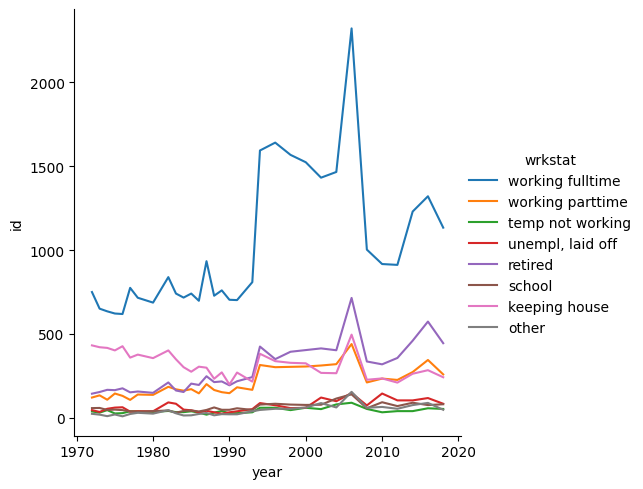

In [ ]:
sns.relplot(data=gb,x='year',y='id',hue ='wrkstat',kind = 'line')

In [ ]:
gb2 = df2.groupby(['year'], as_index = False).count()
gb2

,year,id,wrkstat
0,1972,1613,1613
1,1973,1504,1504
2,1974,1484,1484
3,1975,1490,1490
4,1976,1499,1499
5,1977,1530,1530
6,1978,1532,1532
7,1980,1468,1468
8,1982,1860,1860
9,1983,1599,1599


In [ ]:
gd=gb.merge(gb2,on='year',how = 'inner',suffixes = ('','Total'))
gd

,year,wrkstat,id,idTotal,wrkstatTotal
0,1972,working fulltime,750,1613,1613
1,1972,working parttime,121,1613,1613
2,1972,temp not working,38,1613,1613
3,1972,"unempl, laid off",46,1613,1613
4,1972,retired,144,1613,1613
...,...,...,...,...,...
251,2018,"unempl, laid off",84,2348,2346
252,2018,retired,445,2348,2346
253,2018,school,81,2348,2346
254,2018,keeping house,242,2348,2346


In [ ]:
gd['percentage'] = gd['id']/gd['idTotal']
gd

,year,wrkstat,id,idTotal,wrkstatTotal,percentage
0,1972,working fulltime,750,1613,1613,0.464972
1,1972,working parttime,121,1613,1613,0.075015
2,1972,temp not working,38,1613,1613,0.023559
3,1972,"unempl, laid off",46,1613,1613,0.028518
4,1972,retired,144,1613,1613,0.089275
...,...,...,...,...,...,...
251,2018,"unempl, laid off",84,2348,2346,0.035775
252,2018,retired,445,2348,2346,0.189523
253,2018,school,81,2348,2346,0.034497
254,2018,keeping house,242,2348,2346,0.103066


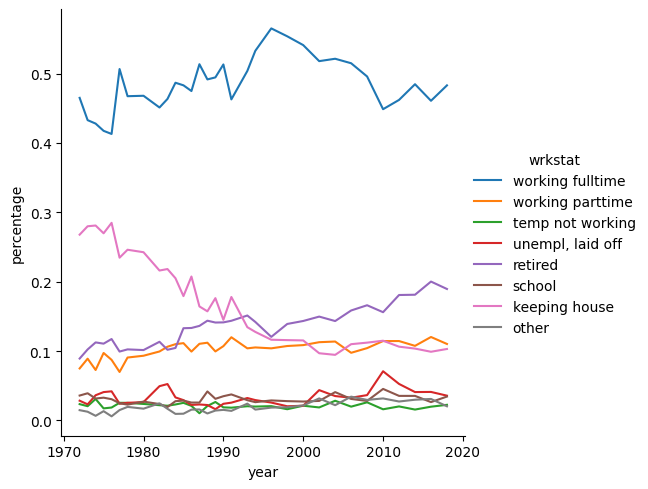

In [ ]:
sns.relplot(data=gd,x='year',y='percentage',hue ='wrkstat',kind = 'line')